# Suite Mass Response: CV / 1P / SB35

For each generated halo in every sim from the **CV**, **1P** and **SB35 (Test)** suites we:

1. Compute its patch-integrated mass in each channel (DM_hydro, Gas, Stars).
2. Extract the equivalent truth patch from the hydro `full_maps.npz` and compute its patch-integrated mass.
3. Compute the per-halo relative difference `(gen - truth) / truth` per channel.
4. Aggregate to **mean ± std** per simulation.
5. Plot a 35-subplot grid (one per CAMELS parameter): x = parameter value, y = per-sim mean relative mass error. SB35 in red, 1P in blue, CV in green.

In [36]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from metrics import CHANNEL_NAMES

plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})

SUITE_ROOT  = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP        = 'snap_090'
MASS_TAG    = 'mass_threshold_1p000e13'
MODEL_NAME  = 'fm_base'
BOX_SIZE    = 50.0
N_PIX_FULL  = 1024
PATCH_PIX   = 128
N_PARAMS    = 35

# Load per-parameter metadata (names and log-scale flags) from the CAMELS SB35 CSV.
_param_meta = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv'
)
# 1-indexed dicts.
PARAM_NAMES = {i+1: name for i, name in enumerate(_param_meta['ParamName'])}
PARAM_LOG   = {i+1: bool(v)  for i, v    in enumerate(_param_meta['LogFlag'])}

SUITE_COLORS  = {'Test': 'tab:red', '1P': 'tab:blue', 'CV': 'tab:green'}
SUITE_SIZES   = {'Test': 5, '1P': 10, 'CV': 10}
SUITE_DISPLAY = {'Test': 'SB35', '1P': '1P', 'CV': 'CV'}

print('Channels :', CHANNEL_NAMES)
print('Log-scale params:', [k for k, v in PARAM_LOG.items() if v])

Channels : ['DM_hydro', 'Gas', 'Stars']
Log-scale params: [3, 4, 5, 6, 10, 11, 14, 16, 18, 19, 22, 23, 24, 25, 26, 27, 29, 31, 35]


## 1. Discover sims across suites

In [35]:
def sim_record(suite_dir: Path, suite_name: str):
    snap_dir  = suite_dir / SNAP
    mass_dir  = snap_dir / MASS_TAG
    model_dir = mass_dir / MODEL_NAME
    rec = {
        'suite': suite_name,
        'sim_id': suite_dir.name,
        'full_maps':     snap_dir  / 'full_maps.npz',
        'halo_catalog':  mass_dir  / 'halo_catalog.npz',
        'generated':     model_dir / 'generated_halos.npz',
    }
    rec['available'] = all(p.exists() for p in
                           (rec['full_maps'], rec['halo_catalog'], rec['generated']))
    return rec

sim_records = []
for suite_name in ['CV', '1P', 'Test']:
    root = SUITE_ROOT / suite_name
    if not root.exists():
        print(f'[skip] {root} missing')
        continue
    for sim_dir in sorted(root.iterdir()):
        if sim_dir.is_dir():
            sim_records.append(sim_record(sim_dir, suite_name))

sims_df = pd.DataFrame(sim_records)
print('Total sims found :', len(sims_df))
print('Available sims   :')
print(sims_df.groupby('suite')['available'].agg(['sum', 'count']))

sims_df = sims_df[sims_df['available']].reset_index(drop=True)
sims_df.head()

Total sims found : 270
Available sims   :
       sum  count
suite            
1P     139    141
CV      27     27
Test   102    102


,suite,sim_id,full_maps,halo_catalog,generated,available
0,CV,sim_0,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_0/sna...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_0/sna...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_0/sna...,True
1,CV,sim_1,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_1/sna...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_1/sna...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_1/sna...,True
2,CV,sim_10,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_10/sn...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_10/sn...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_10/sn...,True
3,CV,sim_11,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_11/sn...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_11/sn...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_11/sn...,True
4,CV,sim_12,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_12/sn...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_12/sn...,/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_12/sn...,True


## 2. Per-halo mass: generated vs truth patches

Truth patches are reconstructed the same way the pipeline extracted them: a periodic `128×128` cutout of the full-box truth map centred on each halo.

In [38]:
def extract_patch(field_2d, cx_pix, cy_pix, size=PATCH_PIX):
    n = field_2d.shape[0]
    half = size // 2
    ix = (cx_pix - half + np.arange(size)) % n
    iy = (cy_pix - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def compute_sim_rel_diff(rec):
    """Return dict with per-halo (gen, truth) total masses and params.

    total masses are (N, 3); params are (35,) (uniform across halos in a sim).
    """
    catalog = np.load(rec['halo_catalog'])
    centers = catalog['centers']                          # (N, 2) in Mpc/h
    params  = catalog['params'][0].astype(np.float64)     # (35,) same for all halos
    gen     = np.load(rec['generated'])['generated']      # (N, 3, 128, 128)
    truth_full = np.load(rec['full_maps'])['truth_maps']  # (3, 1024, 1024)

    n_halos = gen.shape[0]
    gen_mass   = gen.sum(axis=(2, 3)).astype(np.float64)           # (N, 3)
    truth_mass = np.zeros_like(gen_mass)

    ppm = N_PIX_FULL / BOX_SIZE
    for i, (cx_mpc, cy_mpc) in enumerate(centers[:n_halos]):
        cx = int(cx_mpc * ppm) % N_PIX_FULL
        cy = int(cy_mpc * ppm) % N_PIX_FULL
        for c in range(3):
            truth_mass[i, c] = extract_patch(truth_full[c], cx, cy).sum()

    with np.errstate(divide='ignore', invalid='ignore'):
        rel_diff = (gen_mass - truth_mass) / truth_mass   # (N, 3)
        rel_diff[~np.isfinite(rel_diff)] = np.nan

    return {
        'rel_diff':  rel_diff,
        'gen_mass':  gen_mass,
        'truth_mass': truth_mass,
        'params':    params,
        'n_halos':   n_halos,
    }

# Sanity
_probe = compute_sim_rel_diff(sims_df.iloc[0])
print('probe sim:', sims_df.iloc[0]['sim_id'])
print('  rel_diff shape :', _probe['rel_diff'].shape)
print('  median rel_diff per channel :', np.nanmedian(_probe['rel_diff'], axis=0))

probe sim: sim_0
  rel_diff shape : (51, 3)
  median rel_diff per channel : [-0.00171468  0.00422413 -0.09095422]


## 3. Aggregate per-sim statistics

In [39]:
rows = []
for _, rec in sims_df.iterrows():
    try:
        r = compute_sim_rel_diff(rec)
    except Exception as e:
        print(f'[fail] {rec["suite"]}/{rec["sim_id"]}: {e}')
        continue

    mean_rd = np.nanmean(r['rel_diff'], axis=0)   # (3,)
    std_rd  = np.nanstd(r['rel_diff'],  axis=0)   # (3,)

    row = {
        'suite':    rec['suite'],
        'sim_id':   rec['sim_id'],
        'n_halos':  r['n_halos'],
    }
    for c, name in enumerate(CHANNEL_NAMES):
        row[f'mean_rd_{name}'] = float(mean_rd[c])
        row[f'std_rd_{name}']  = float(std_rd[c])
    for k in range(N_PARAMS):
        row[f'p{k+1}'] = float(r['params'][k])
    rows.append(row)

sim_stats = pd.DataFrame(rows)
print(f'Aggregated {len(sim_stats)} sims across {sim_stats.suite.nunique()} suites.')
print(sim_stats.groupby('suite').size().rename('n_sims'))

# Drop sims with too few halos for a reliable per-sim mean.
MIN_HALOS = 1
low_halo = sim_stats['n_halos'] < MIN_HALOS
if low_halo.any():
    print(f'Dropping {low_halo.sum()} sim(s) with n_halos < {MIN_HALOS}:')
    print(sim_stats.loc[low_halo, ['suite', 'sim_id', 'n_halos']].to_string(index=False))
    sim_stats = sim_stats[~low_halo].reset_index(drop=True)

print(f'Remaining sims: {len(sim_stats)}')

# Build one fixed y-axis range shared by all channel figures and all 35 panels.
all_y = []
for name in CHANNEL_NAMES:
    m = sim_stats[f'mean_rd_{name}'].to_numpy(dtype=np.float64)
    s = sim_stats[f'std_rd_{name}'].to_numpy(dtype=np.float64)
    all_y.extend((m - s).tolist())
    all_y.extend((m + s).tolist())
all_y = np.asarray(all_y, dtype=np.float64)
all_y = all_y[np.isfinite(all_y)]

if all_y.size:
    y_min = float(all_y.min())
    y_max = float(all_y.max())
    if y_max == y_min:
        y_pad = 0.05 * (abs(y_max) + 1.0)
    else:
        y_pad = 0.06 * (y_max - y_min)
    FIXED_YLIM = (y_min - y_pad, y_max + y_pad)
else:
    FIXED_YLIM = (-1.0, 1.0)

print(f'Using fixed y-limits for all figures: {FIXED_YLIM}')
sim_stats.head()

Aggregated 268 sims across 3 suites.
suite
1P      139
CV       27
Test    102
Name: n_sims, dtype: int64
Remaining sims: 268
Using fixed y-limits for all figures: (-0.7303664750996195, 2.78225125114726)


,suite,sim_id,n_halos,mean_rd_DM_hydro,std_rd_DM_hydro,mean_rd_Gas,std_rd_Gas,mean_rd_Stars,std_rd_Stars,p1,...,p26,p27,p28,p29,p30,p31,p32,p33,p34,p35
0,CV,sim_0,51,-0.002025,0.004447,0.002625,0.014410,-0.080842,0.105815,0.3,...,0.2,0.002,2.0,1.0,0.0,1.0,0.0,0.0013,1.12,2.0
1,CV,sim_1,62,-0.001485,0.004269,0.002225,0.015881,-0.084651,0.099266,0.3,...,0.2,0.002,2.0,1.0,0.0,1.0,0.0,0.0013,1.12,2.0
2,CV,sim_10,39,-0.001240,0.003946,0.002214,0.014160,-0.089784,0.102321,0.3,...,0.2,0.002,2.0,1.0,0.0,1.0,0.0,0.0013,1.12,2.0
3,CV,sim_11,58,-0.001657,0.004142,0.003711,0.014025,-0.101562,0.107795,0.3,...,0.2,0.002,2.0,1.0,0.0,1.0,0.0,0.0013,1.12,2.0
4,CV,sim_12,46,-0.002506,0.006786,0.003519,0.018294,-0.118662,0.087963,0.3,...,0.2,0.002,2.0,1.0,0.0,1.0,0.0,0.0013,1.12,2.0


## 4. 35-subplot parameter response

One figure per channel. Each subplot fixes a parameter and plots per-sim mean relative
mass error vs that parameter value, with error bars from the per-sim std. SB35 red,
1P blue, CV green.

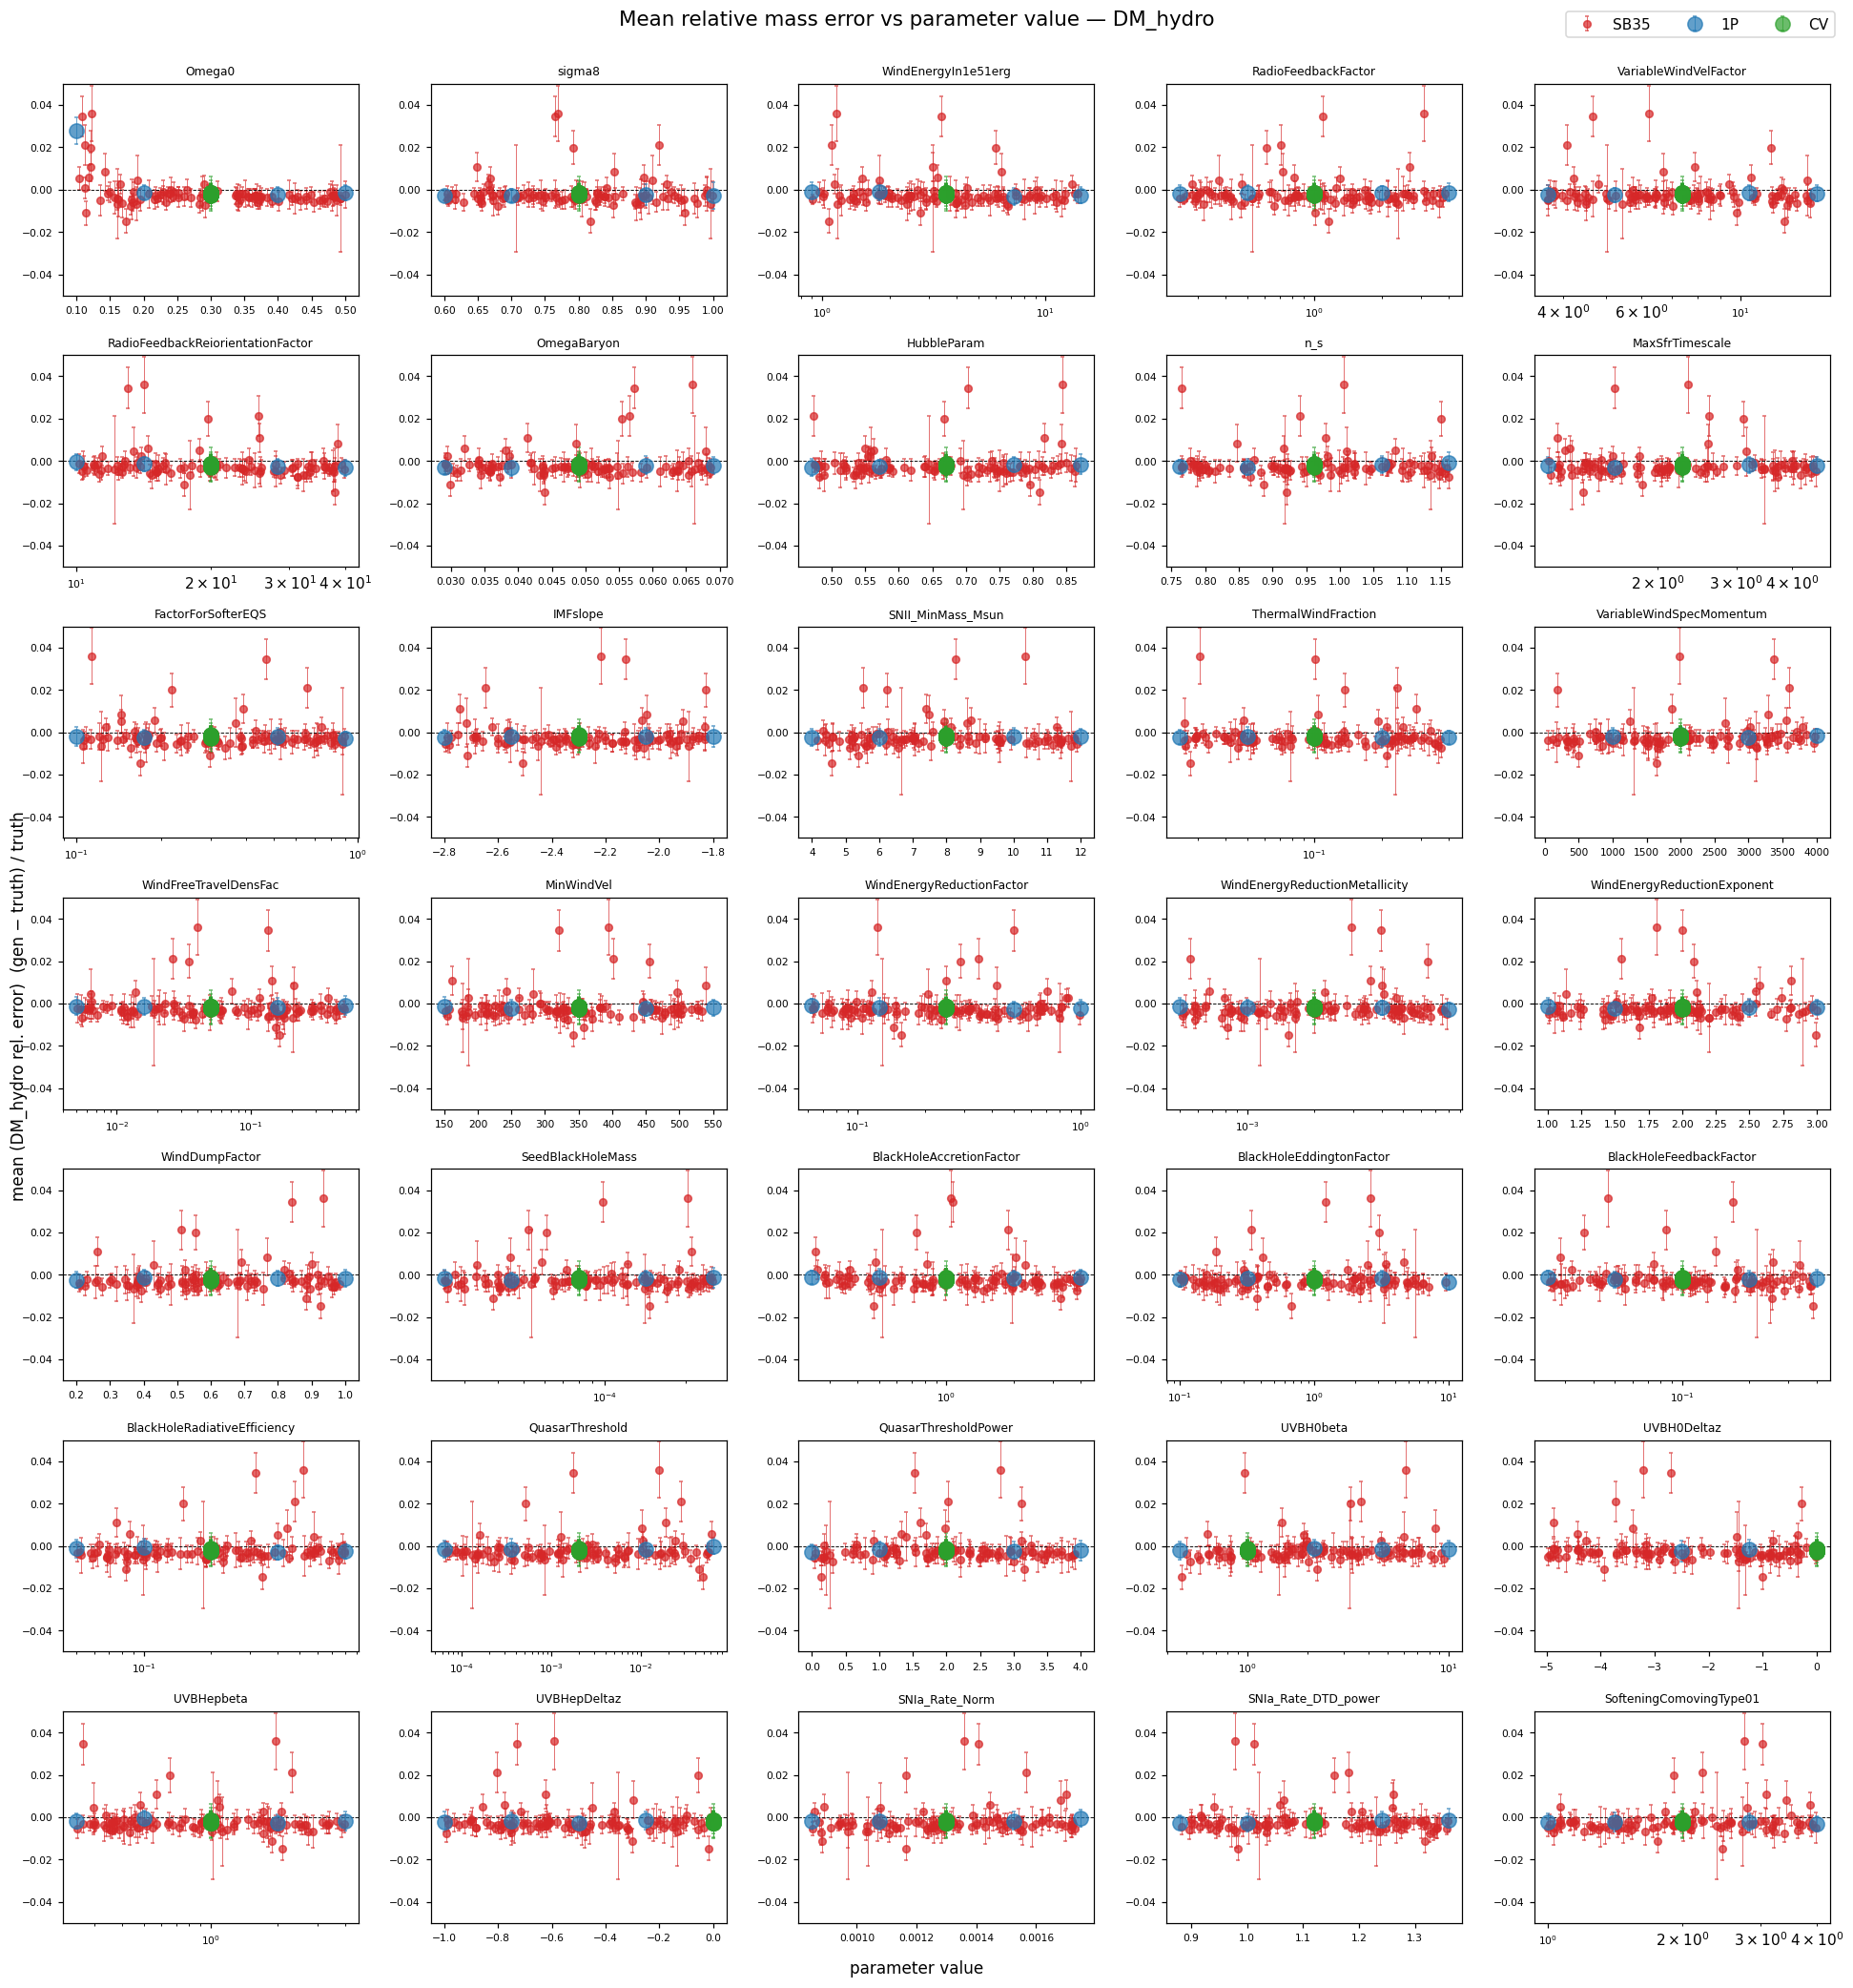

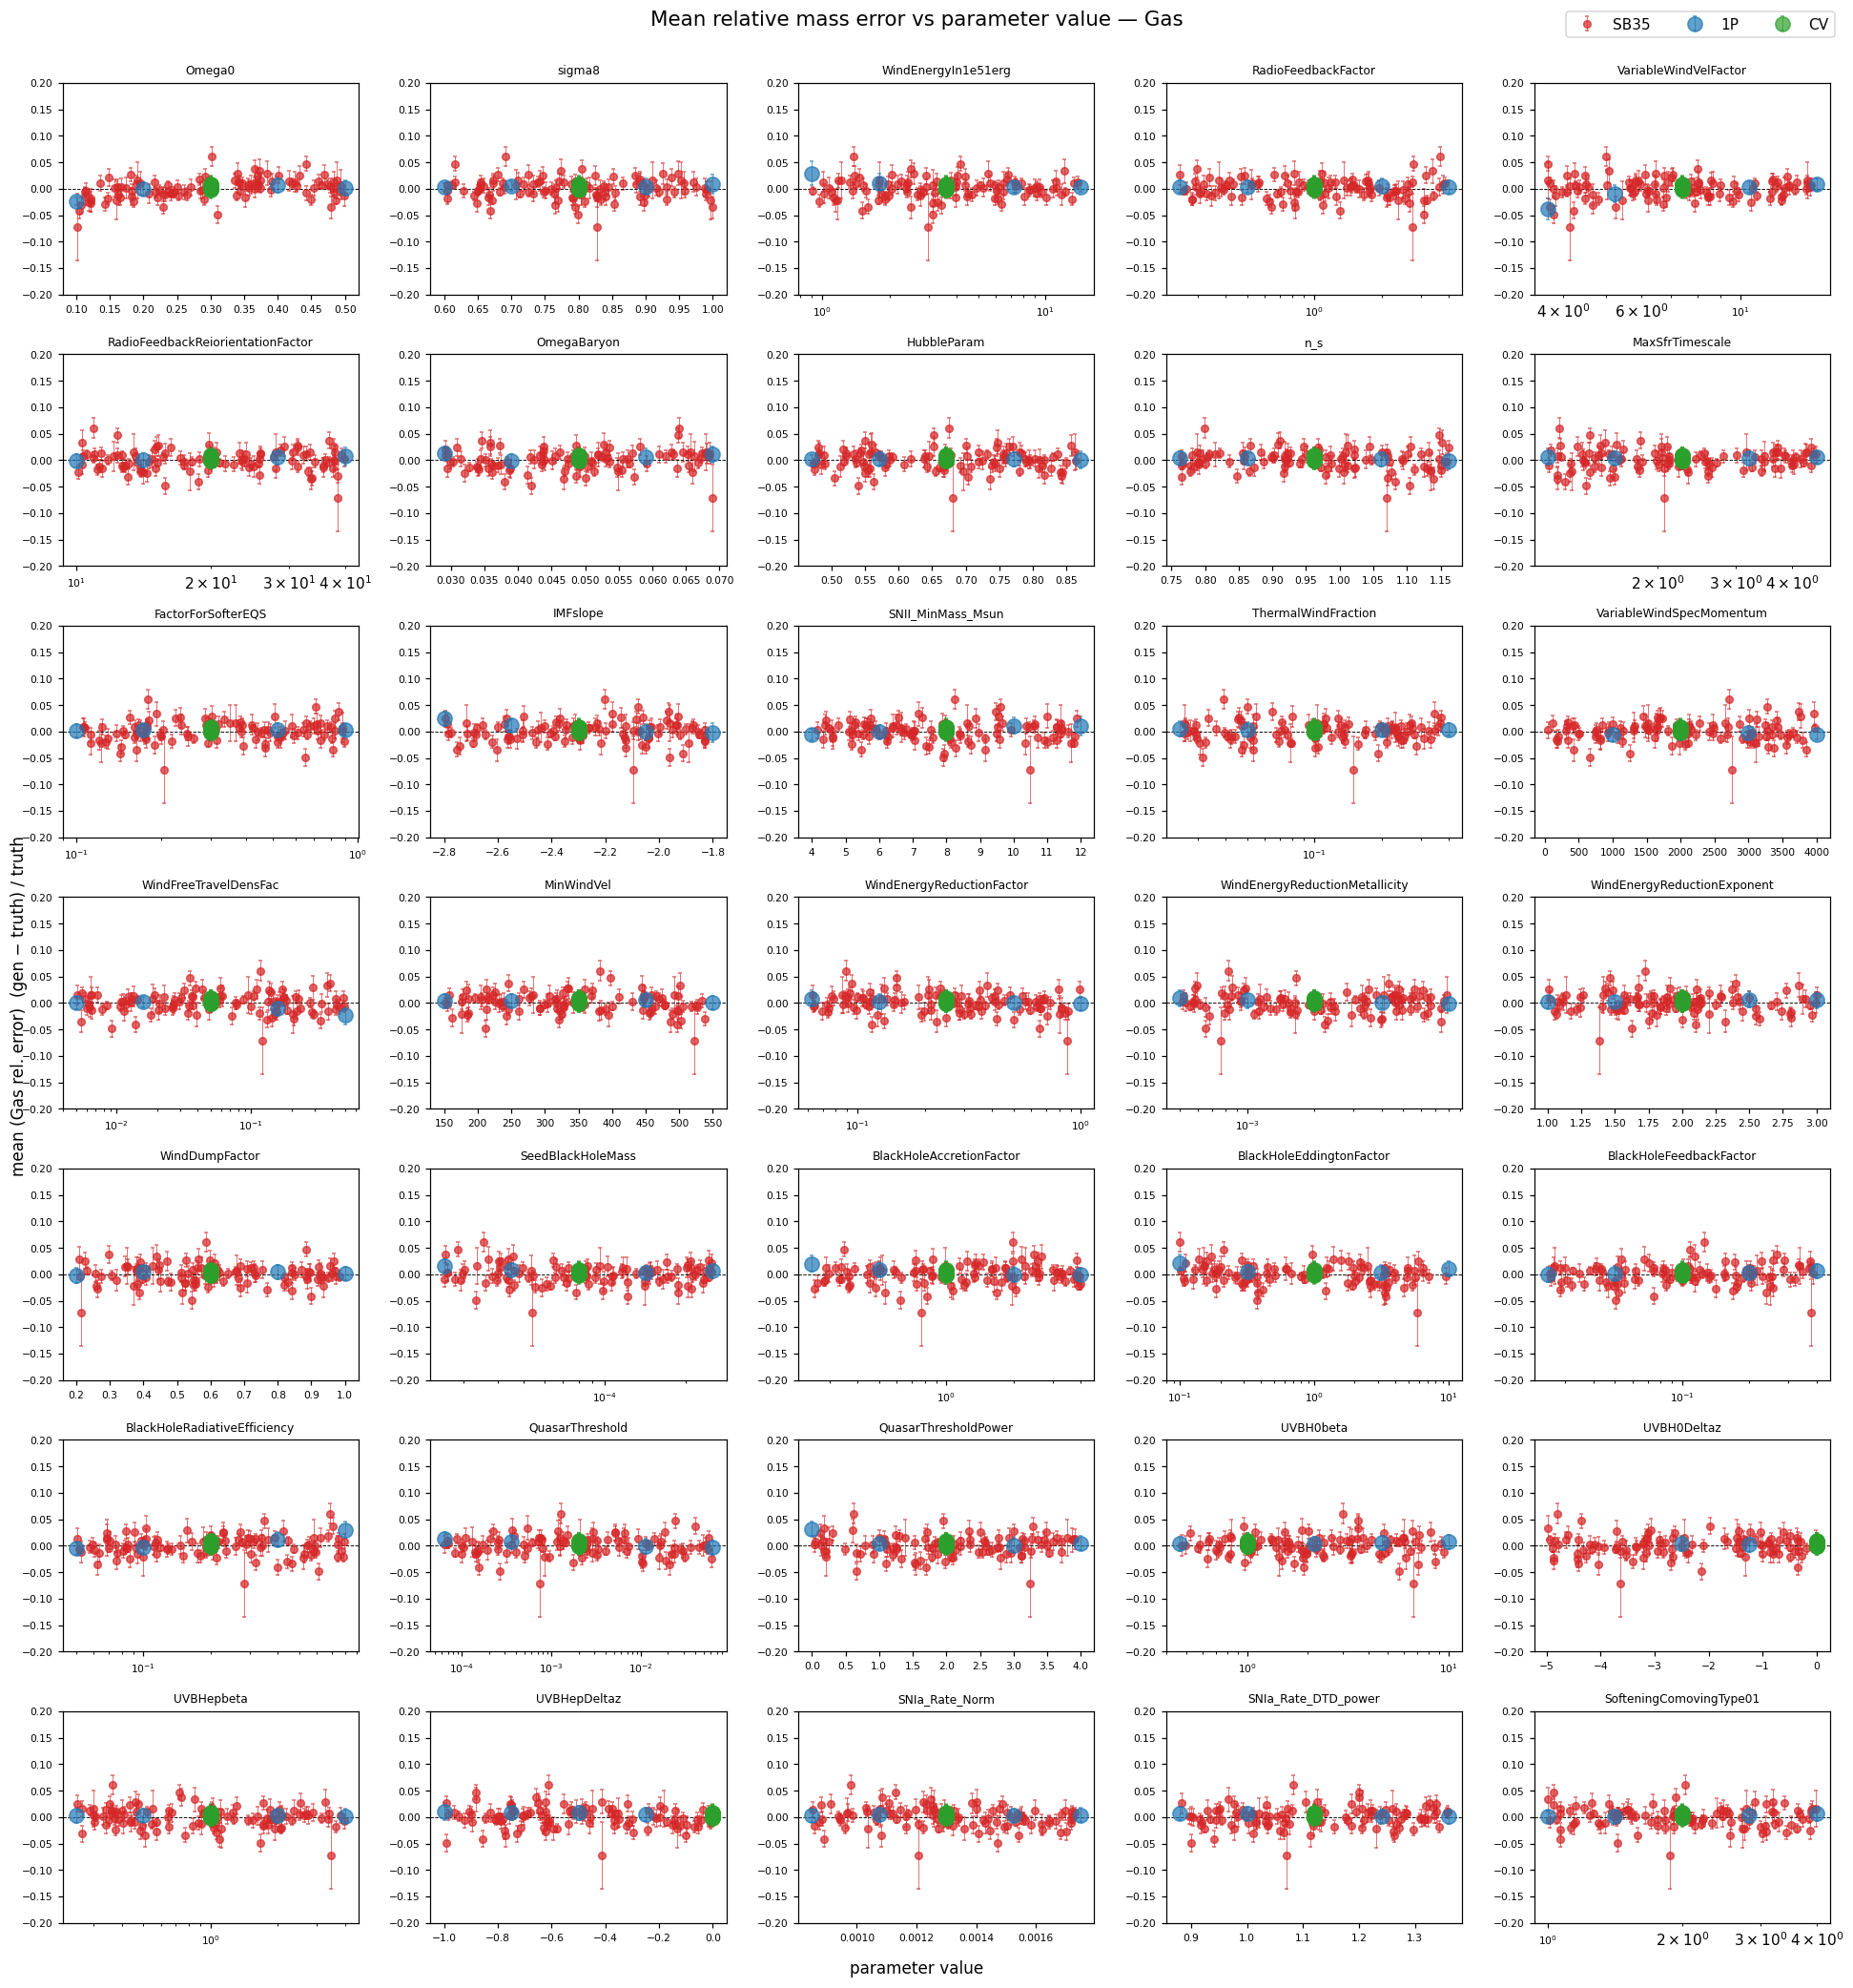

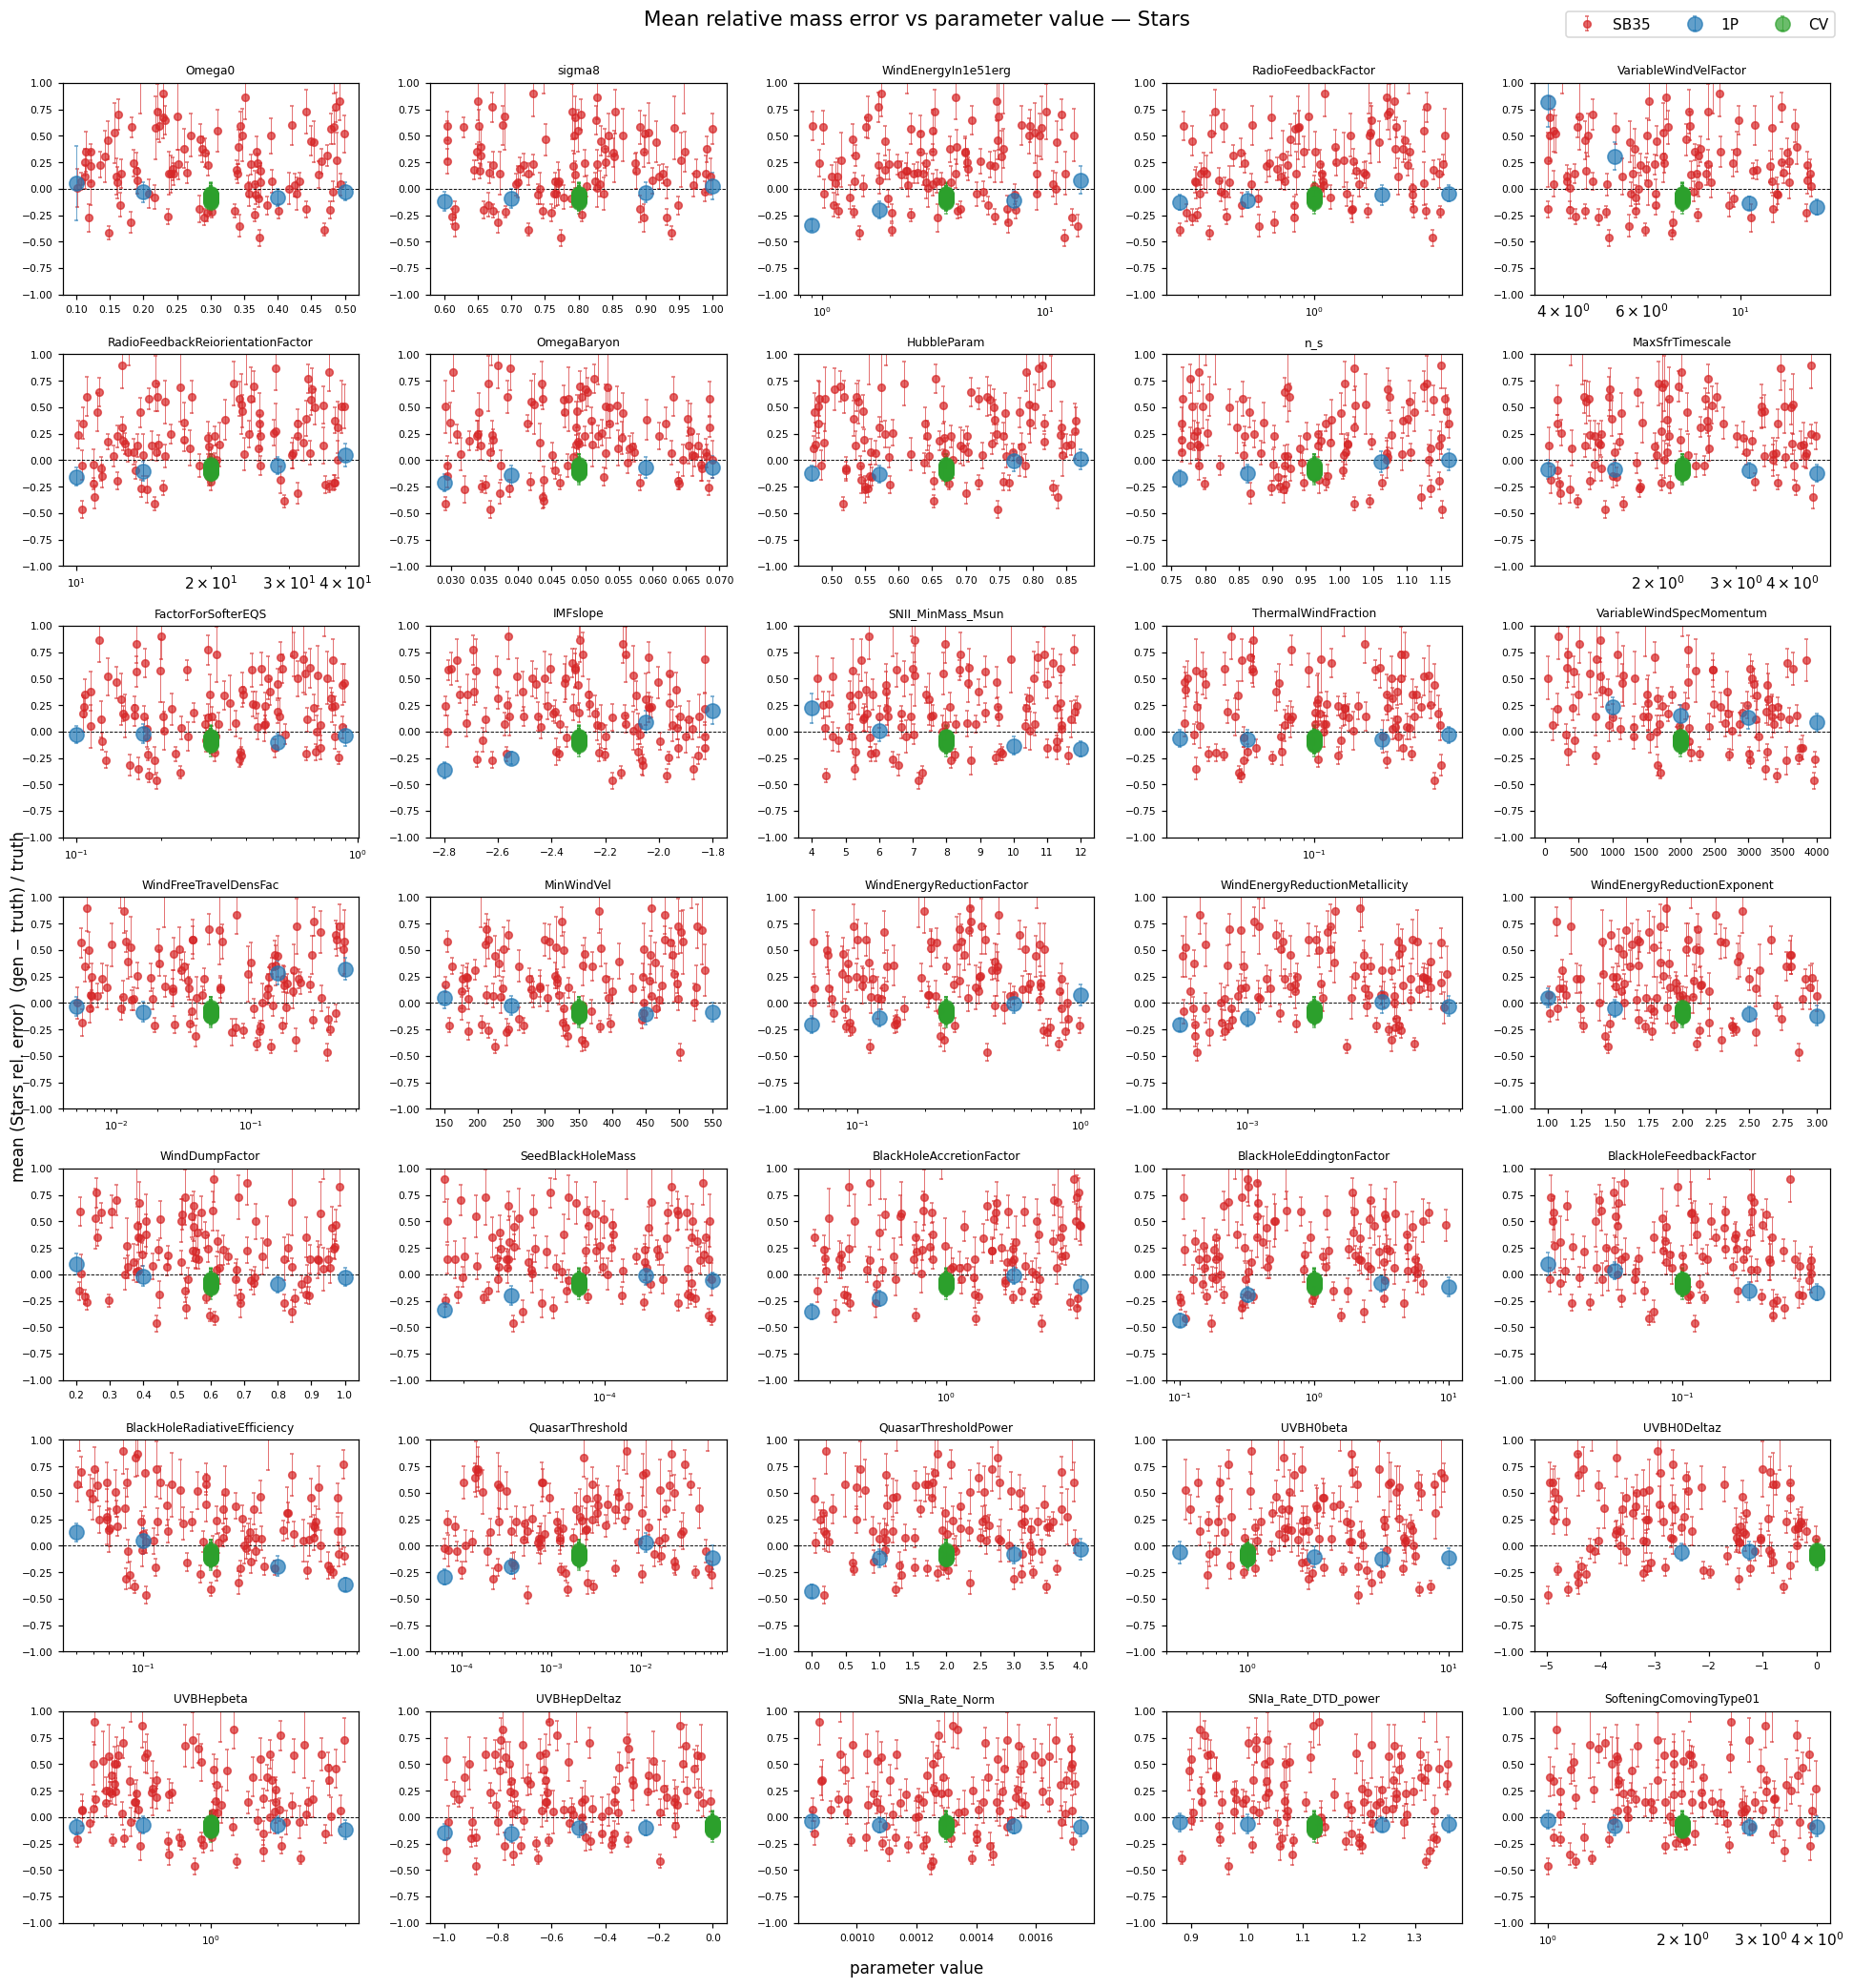

In [40]:
def plot_param_response(
    channel_idx: int,
    *,
    show_errorbars: bool = True,
    ncols: int = 5,
    y_limits=None,
):
    ch_name = CHANNEL_NAMES[channel_idx]
    mean_col = f'mean_rd_{ch_name}'
    std_col  = f'std_rd_{ch_name}'

    if y_limits is None:
        y_limits = FIXED_YLIM

    nrows = int(np.ceil(N_PARAMS / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.6 * ncols, 2.7 * nrows),
                             squeeze=False)
    fig.suptitle(
        f'Mean relative mass error vs parameter value — {ch_name}',
        fontsize=14, y=1.002,
    )

    for k in range(N_PARAMS):
        ax = axes[k // ncols, k % ncols]
        pcol = f'p{k+1}'
        for suite in ['Test', '1P', 'CV']:
            sub = sim_stats[sim_stats['suite'] == suite]
            # For 1P, only show the 5 sims that vary parameter k+1.
            # The other 34 groups all sit at the fiducial value and
            # would create a spurious dense cluster there.
            if suite == '1P':
                sub = sub[sub['sim_id'].str.startswith(f'1P_p{k+1}_')]
            if sub.empty:
                continue
            x = sub[pcol].to_numpy()
            y = sub[mean_col].to_numpy()
            yerr = sub[std_col].to_numpy() if show_errorbars else None
            color = SUITE_COLORS[suite]
            label = SUITE_DISPLAY[suite]
            size = SUITE_SIZES[suite]
            if show_errorbars:
                ax.errorbar(x, y, yerr=yerr,
                            fmt='o', ms=size, lw=0.6, alpha=0.7,
                            color=color, ecolor=color, label=label,
                            capsize=1.5)
            else:
                ax.scatter(x, y, s=size, alpha=0.75, color=color, label=label)
        ax.axhline(0, color='k', lw=0.6, ls='--')
        if PARAM_LOG.get(k+1):
            ax.set_xscale('log')
        ax.set_ylim(*y_limits)
        ax.set_title(PARAM_NAMES.get(k+1, f'p{k+1}'), fontsize=8)
        ax.tick_params(labelsize=7)

    # Blank unused axes
    for k in range(N_PARAMS, nrows * ncols):
        axes[k // ncols, k % ncols].axis('off')

    # Shared axis labels + one legend
    fig.supxlabel('parameter value', fontsize=11)
    fig.supylabel(f'mean ({ch_name} rel. error)  (gen − truth) / truth', fontsize=11)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper right', ncol=3, fontsize=10,
                   bbox_to_anchor=(0.99, 1.005))

    plt.tight_layout()
    return fig


# Per-channel y-limits.
CHANNEL_YLIMS = {
    'DM_hydro': (-0.05, 0.05),
    'Gas':      (-0.2, 0.2),
    'Stars':    (-1.0, 1.0),
}

for c in range(len(CHANNEL_NAMES)):
    ylim = CHANNEL_YLIMS.get(CHANNEL_NAMES[c], FIXED_YLIM)
    plot_param_response(c, show_errorbars=True, y_limits=ylim)
    plt.show()

## 5. Same plot without error bars (cleaner overview)

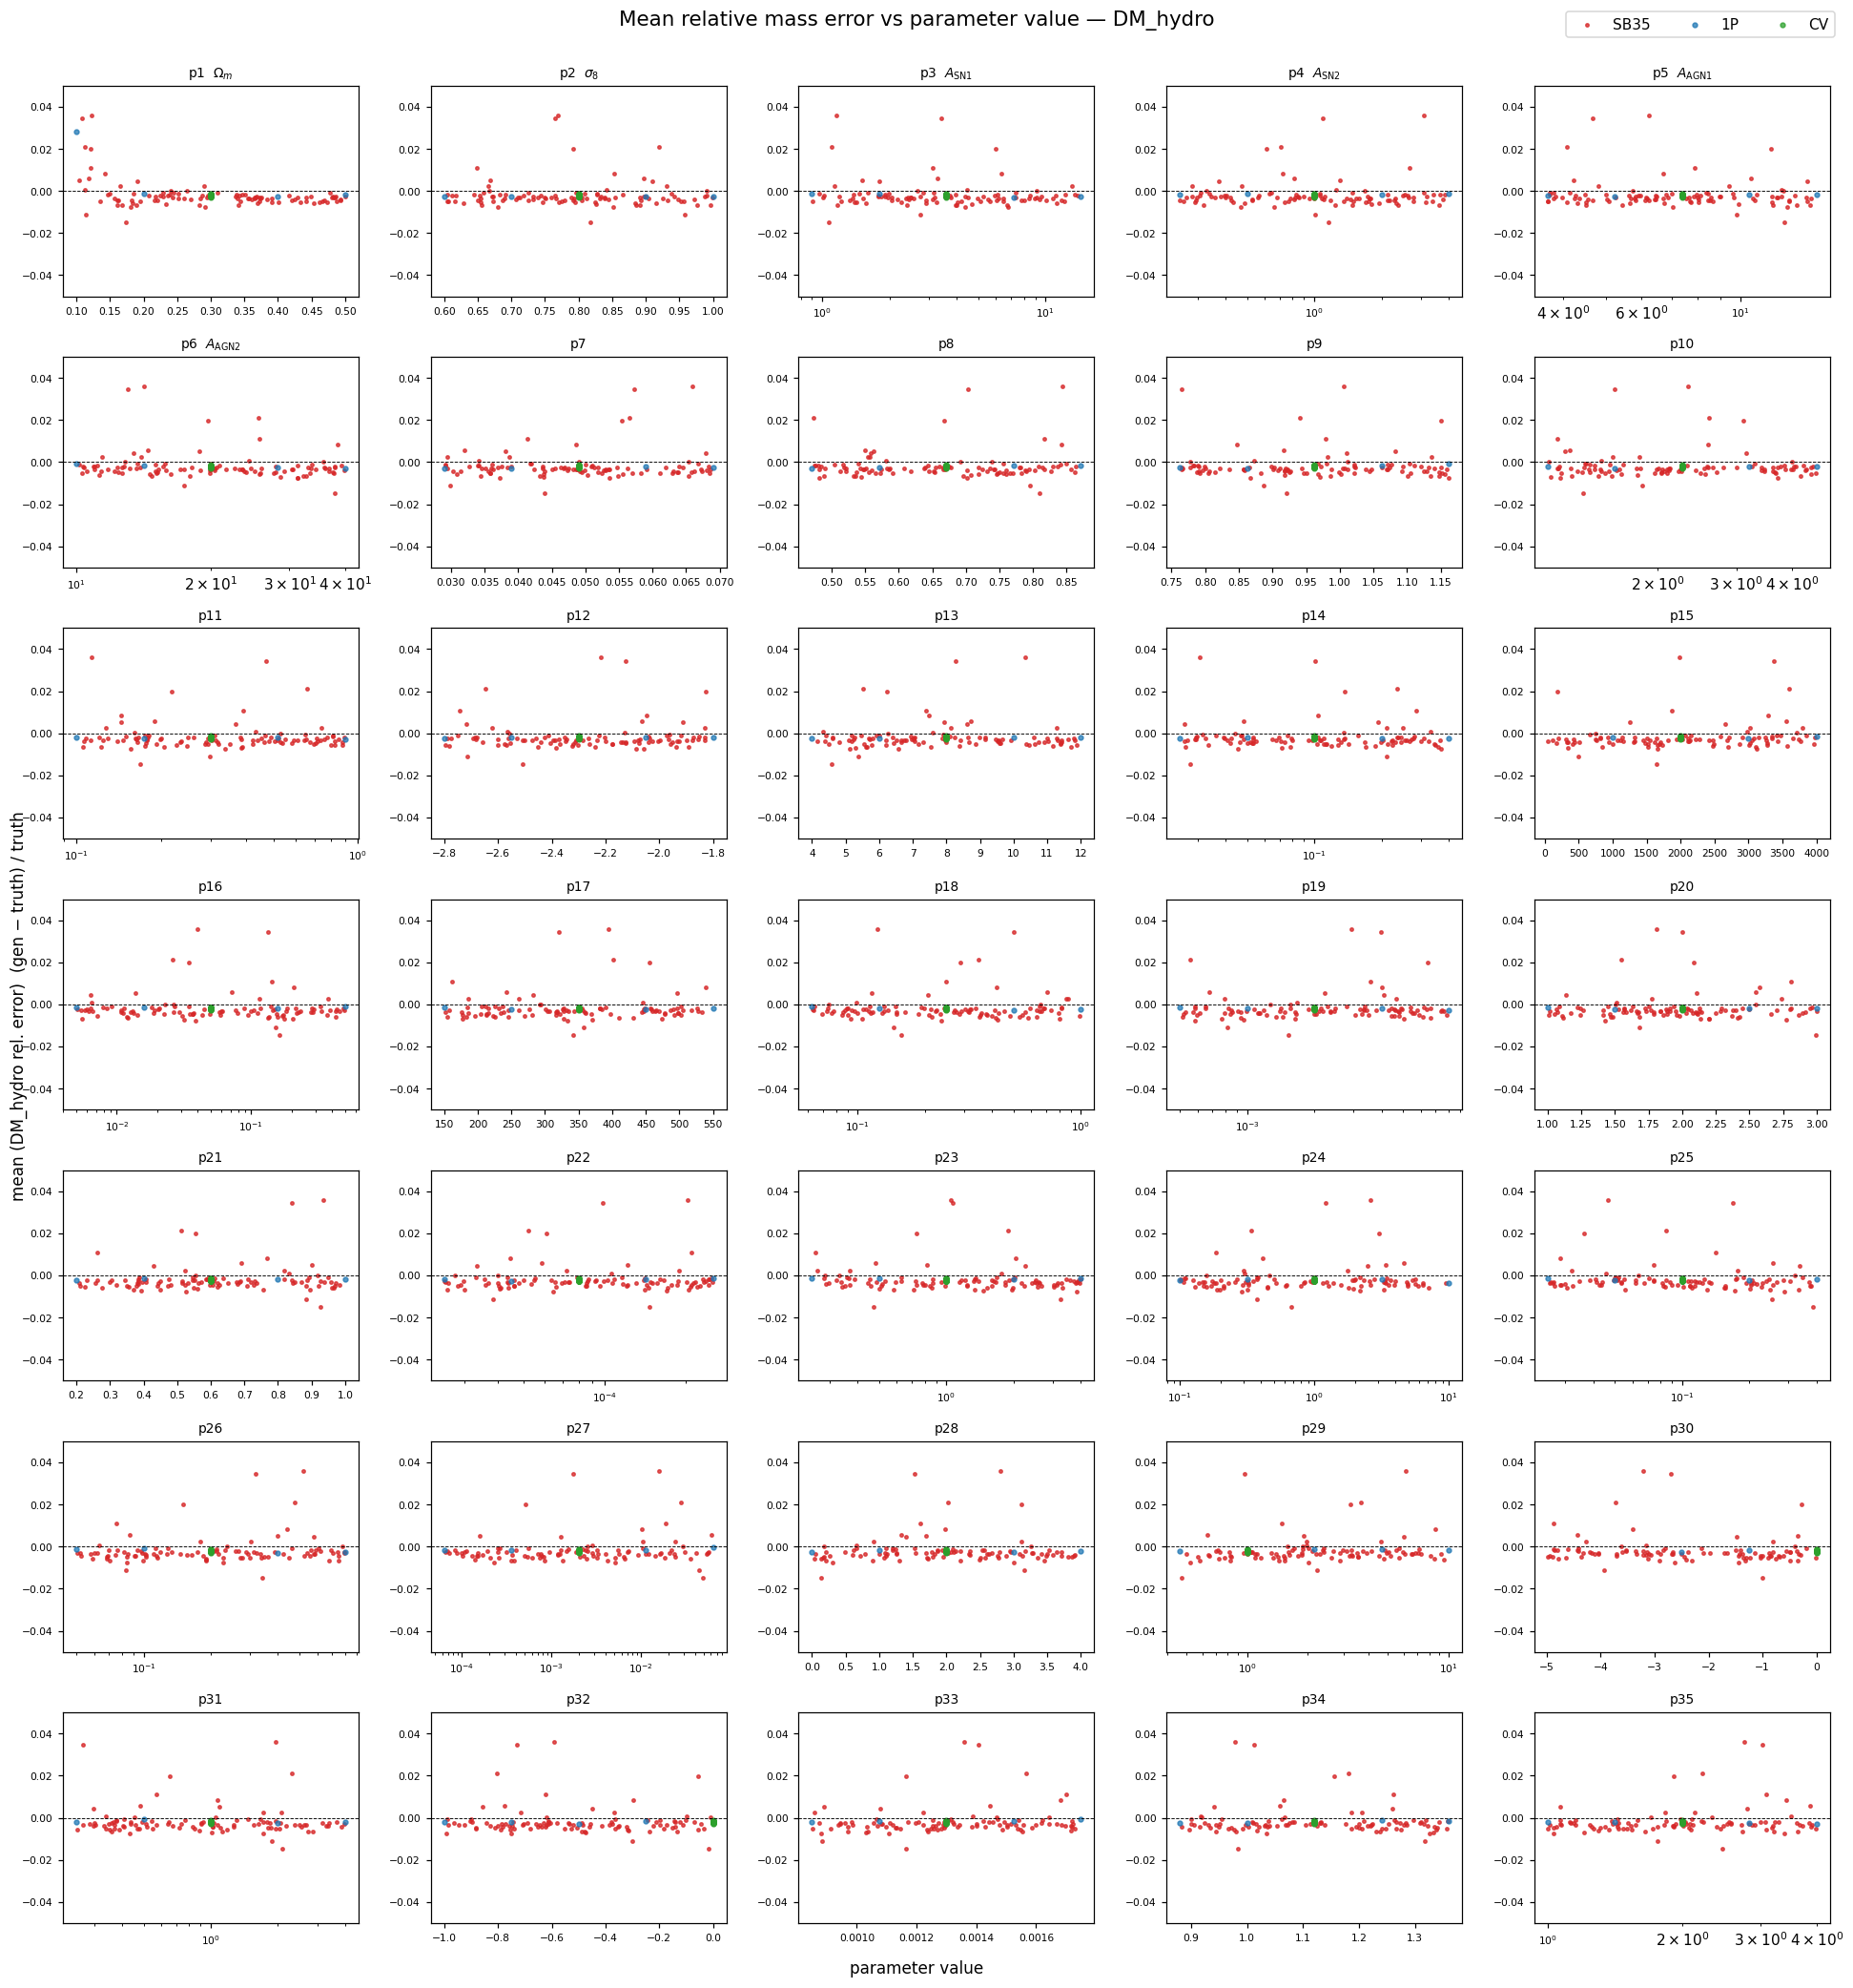

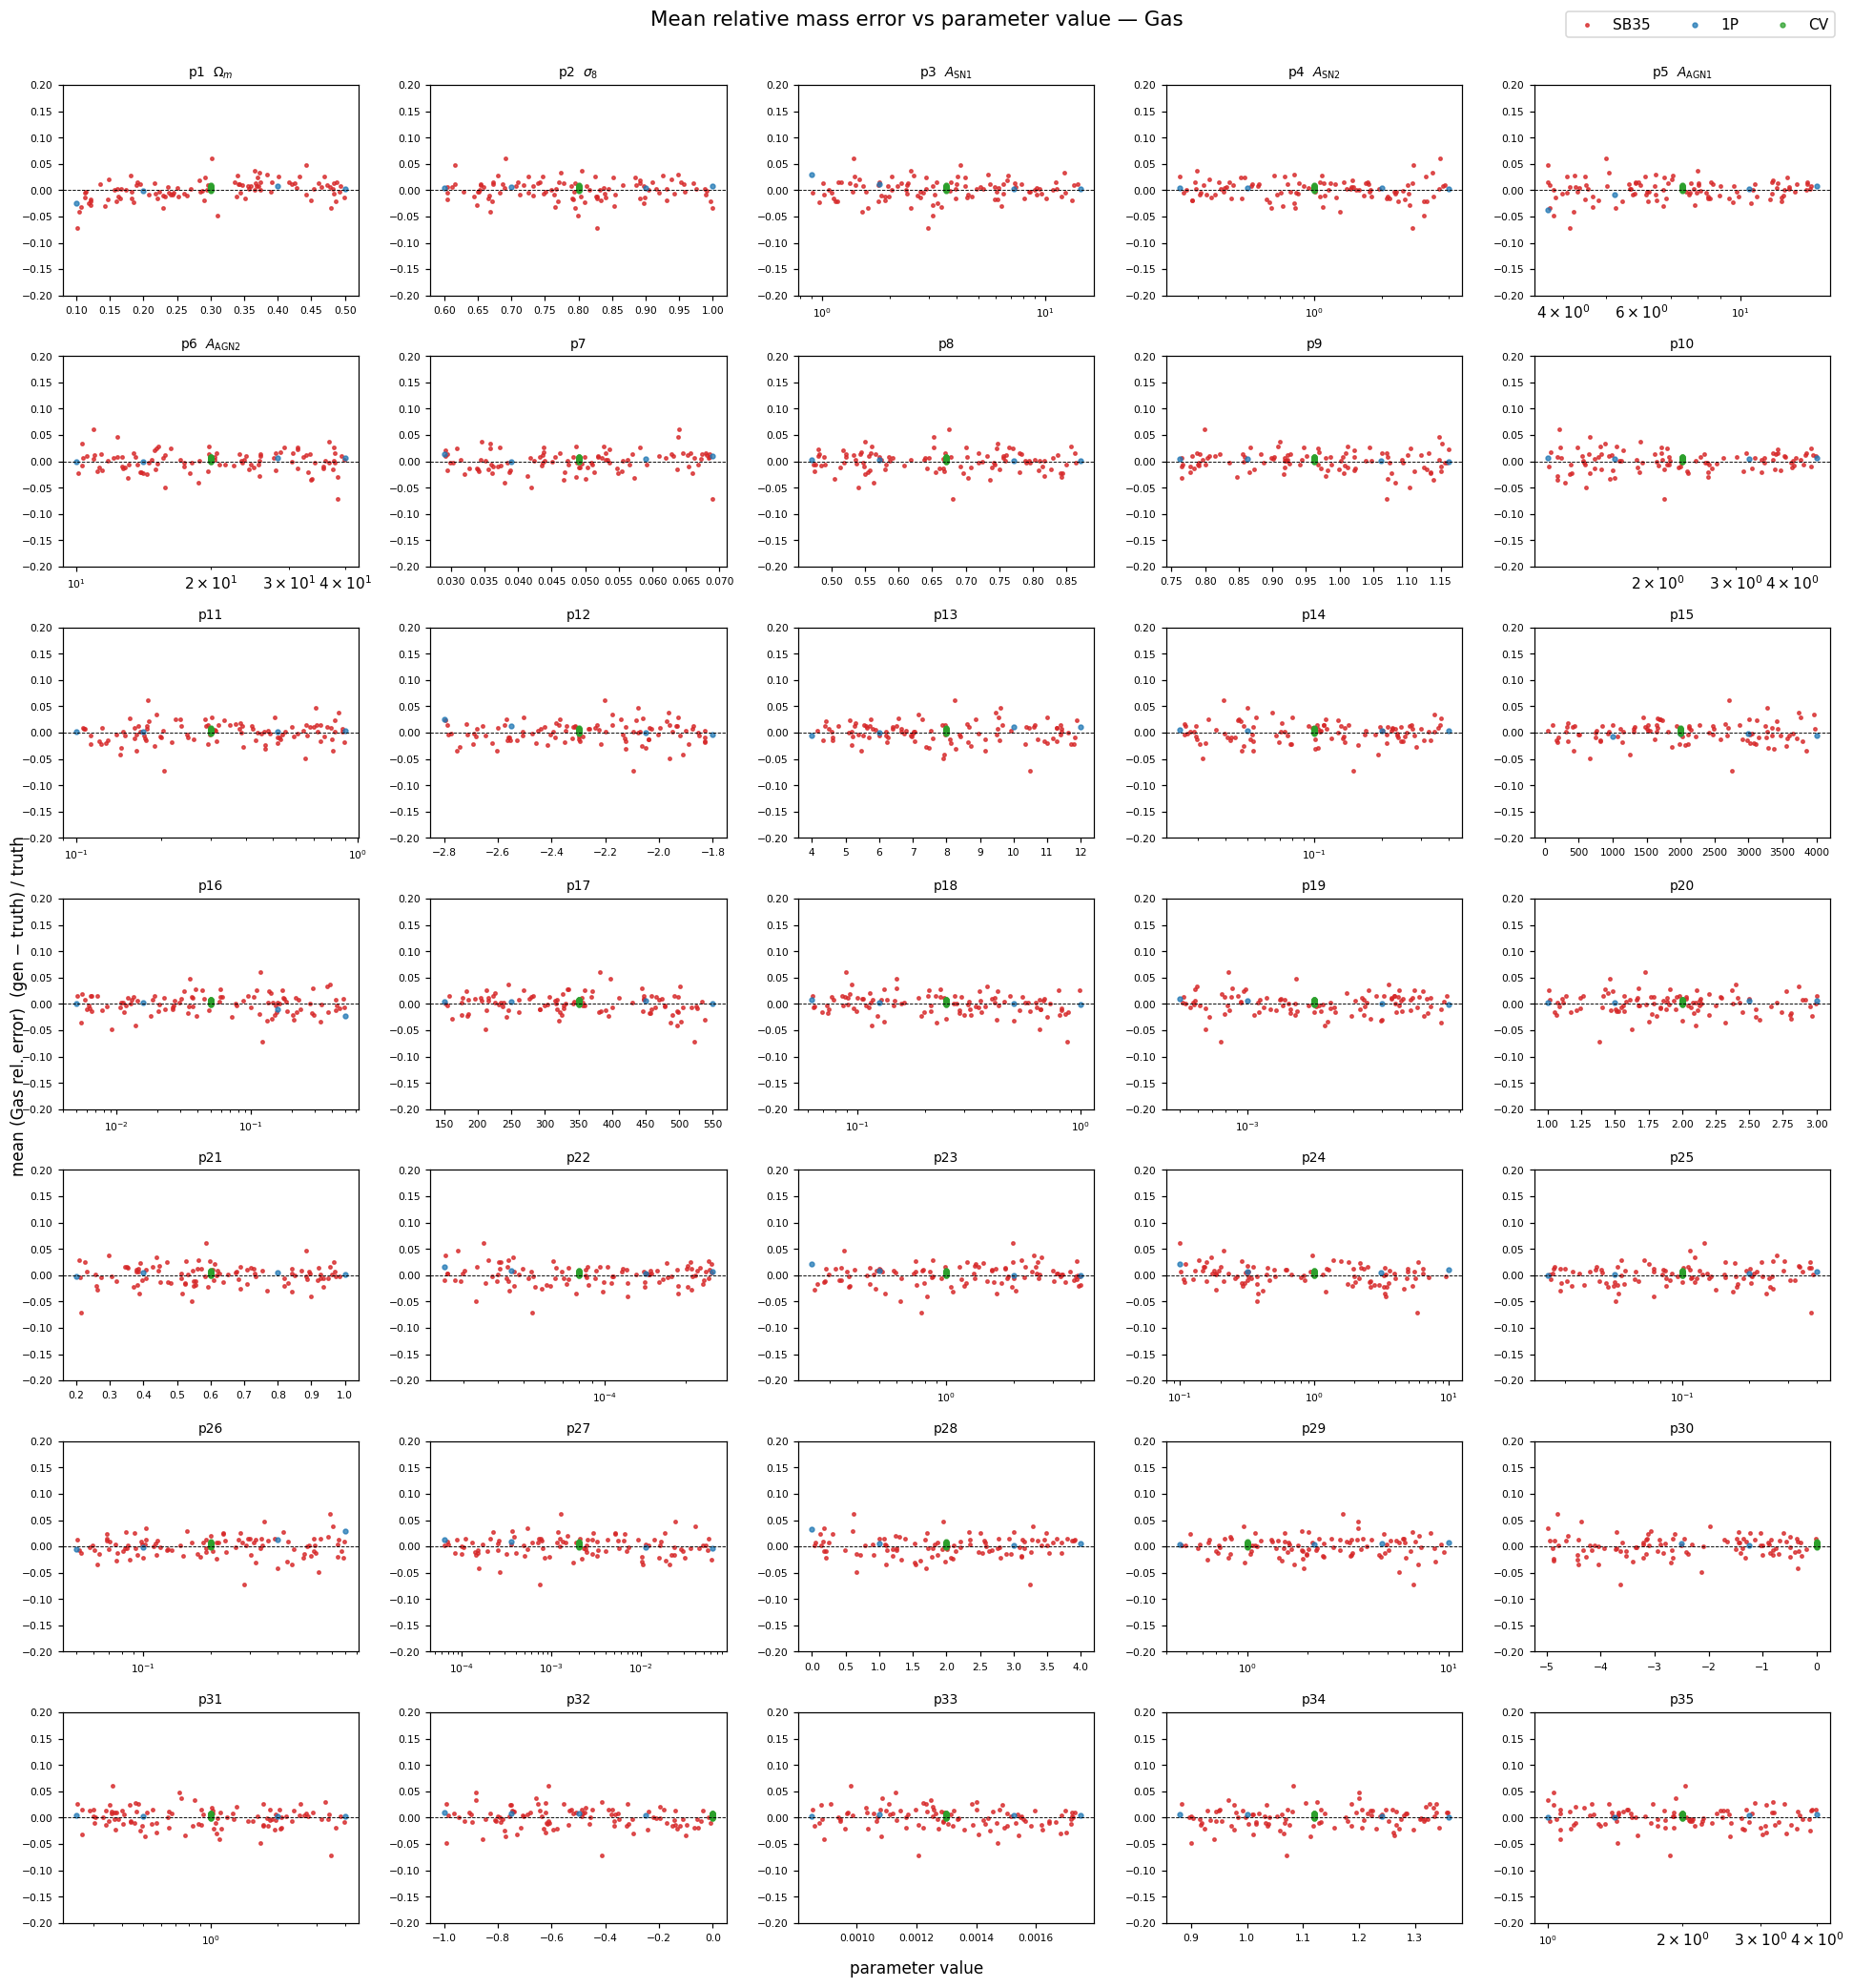

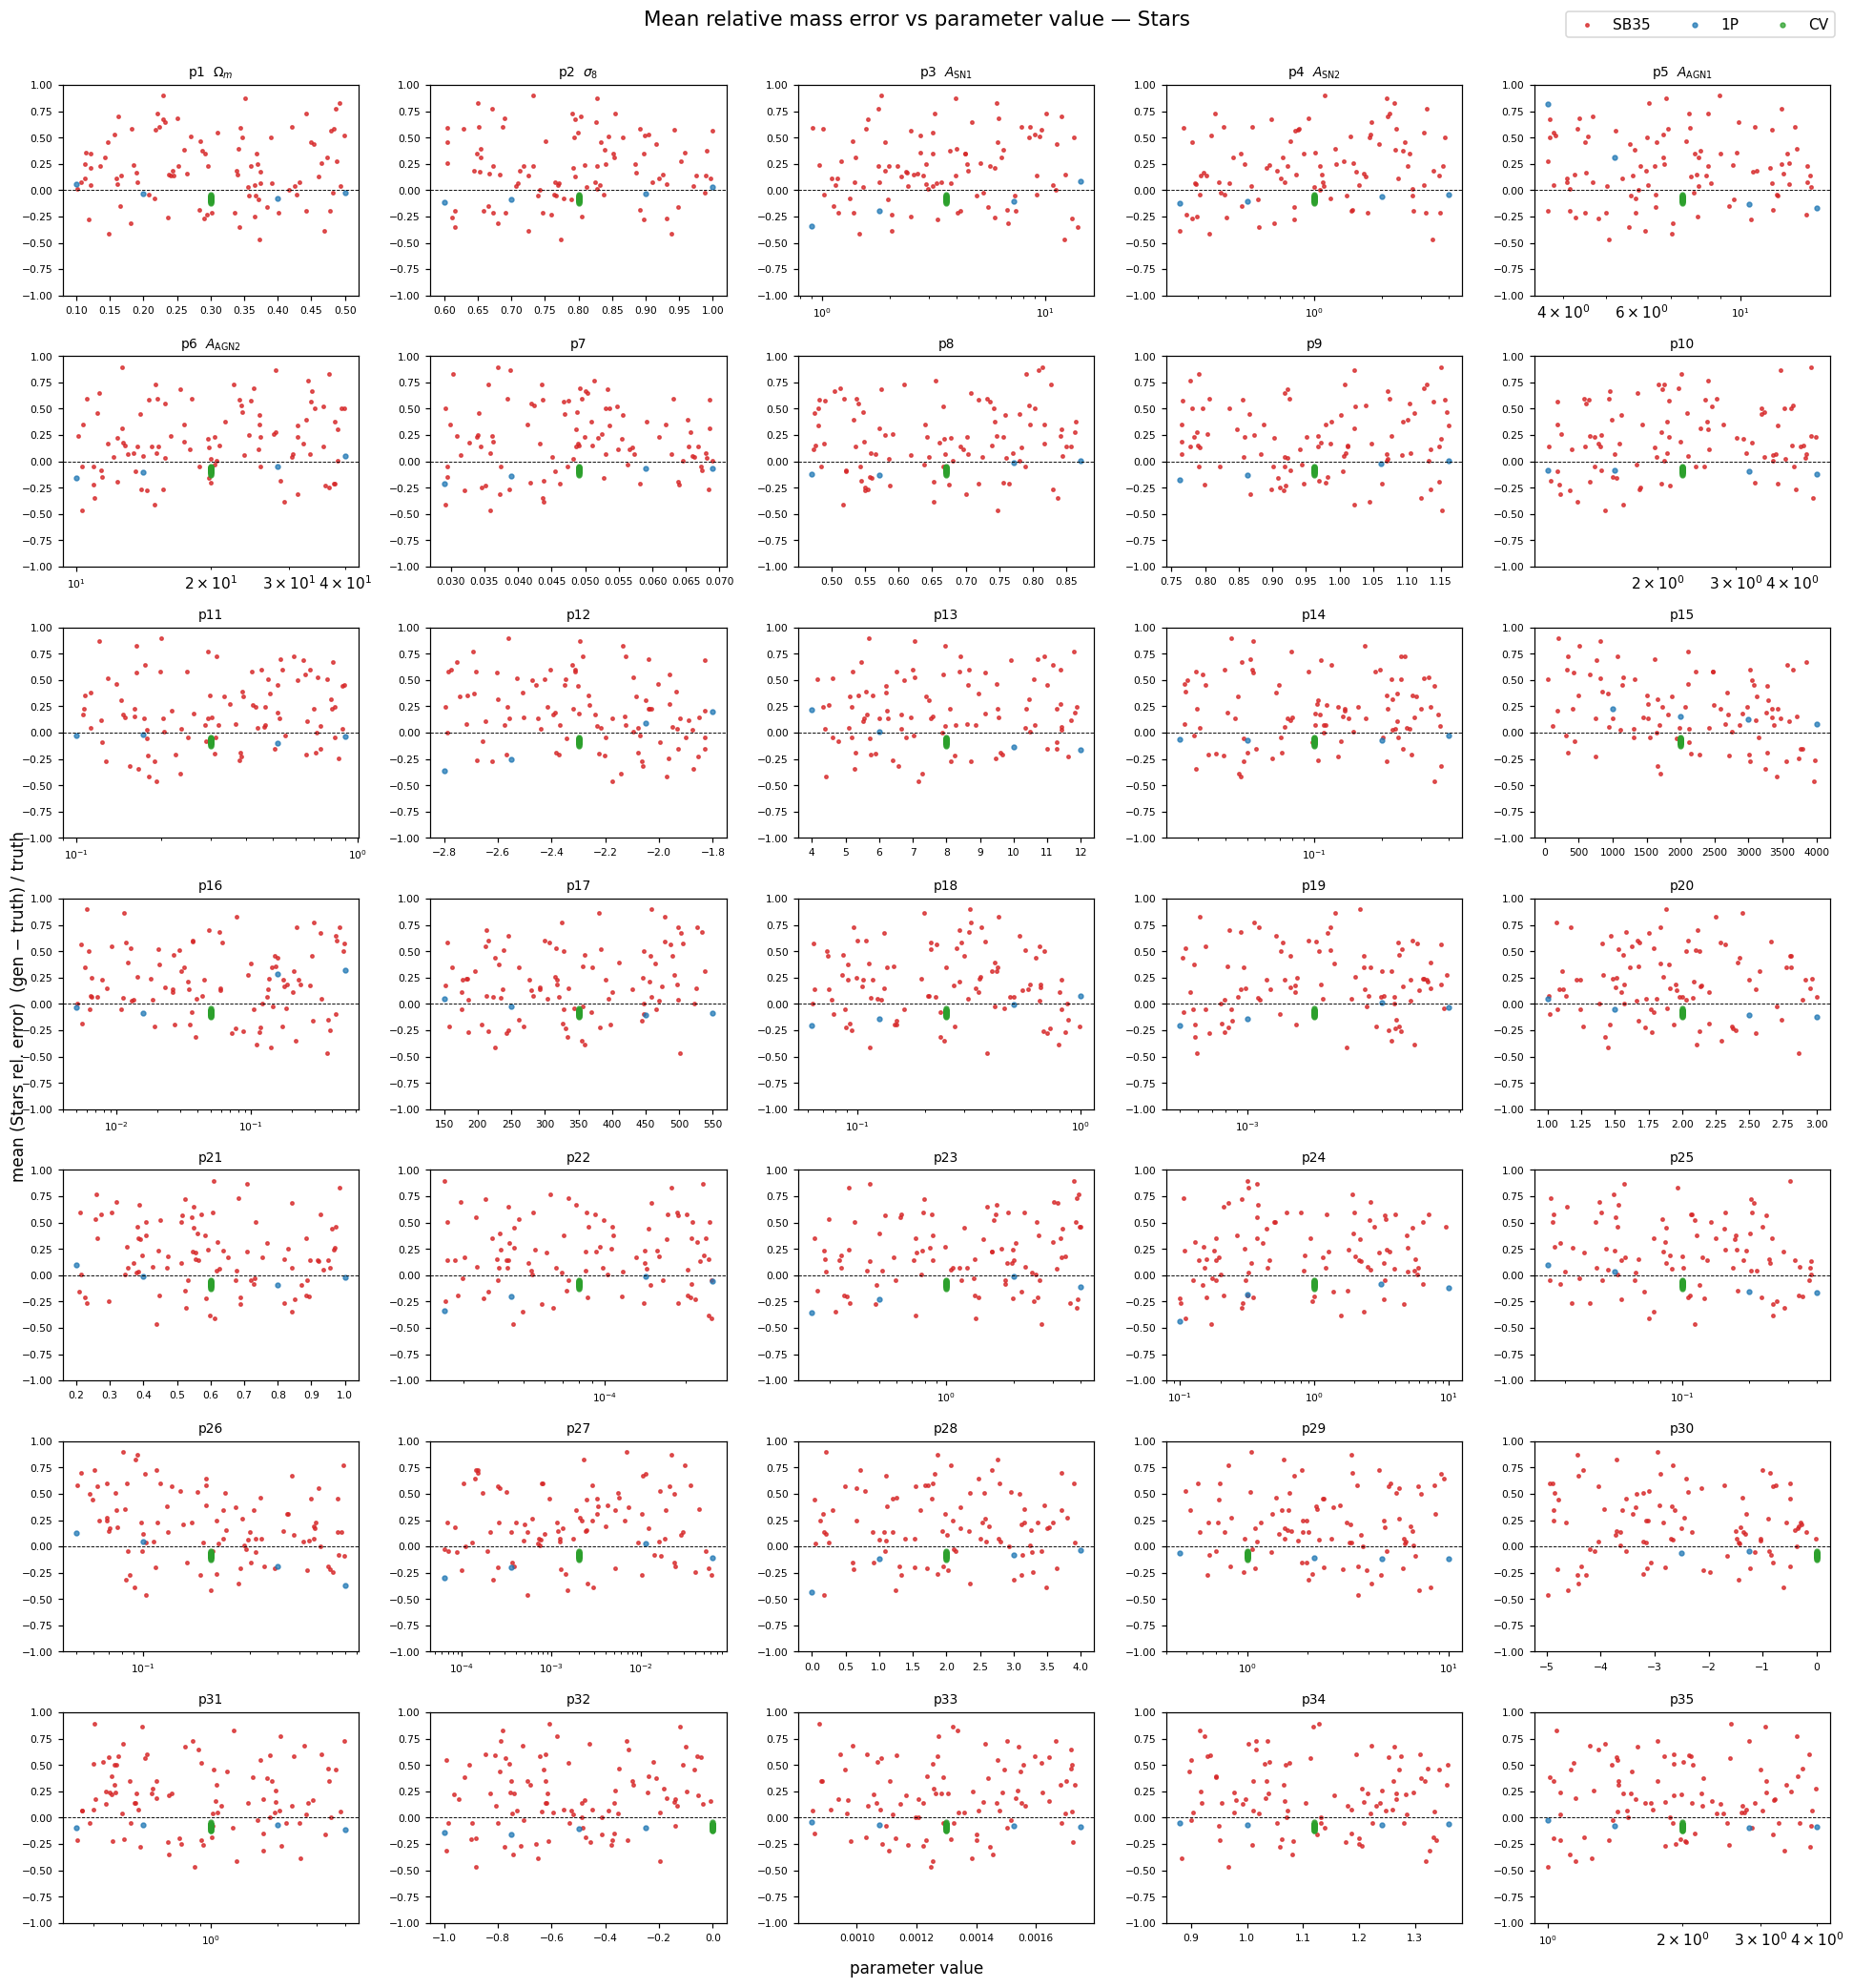

In [30]:
for c in range(len(CHANNEL_NAMES)):
    ylim = CHANNEL_YLIMS.get(CHANNEL_NAMES[c], FIXED_YLIM)
    plot_param_response(c, show_errorbars=False, y_limits=ylim)
    plt.show()